# Endoscopic Heart-Beat Tracker — Demo

Interactive walkthrough of the full pipeline:
1. Inspect the input video
2. Visualise a single frame pair (optical flow)
3. Plot the heartbeat magnitude signal
4. Run the full annotated video export

**Before running:** download the dataset and set `VIDEO_PATH` below.
```bash
python scripts/download_data.py
```

In [1]:
import sys
sys.path.insert(0, '../src')   # make src/ importable from notebooks/

from pathlib import Path
import collections

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display
from PIL import Image

import tracker
import visualizer
import utils

# ── SET THIS to your downloaded video ──────────────────────────────────────
VIDEO_PATH = Path('../data/hamlyn_seq04.avi')
OUTPUT_PATH = Path('../outputs/demo_flow.mp4')
# ───────────────────────────────────────────────────────────────────────────

assert VIDEO_PATH.exists(), f'Video not found: {VIDEO_PATH}. Run: python scripts/download_data.py'

## 1. Video metadata

In [2]:
info = utils.video_info(VIDEO_PATH)
for k, v in info.items():
    print(f'  {k:<14}: {v}')

  path          : C:\Users\dprad\Downloads\heart-beat-tracker\data\hamlyn_seq04.avi
  width         : 360
  height        : 288
  fps           : 25.0
  frame_count   : 1573
  duration_s    : 62.92
  codec         : FMP4


## 2. Single frame pair — optical flow

Phase at frame 786: DIASTOLE  (mean mag = 0.65 px)


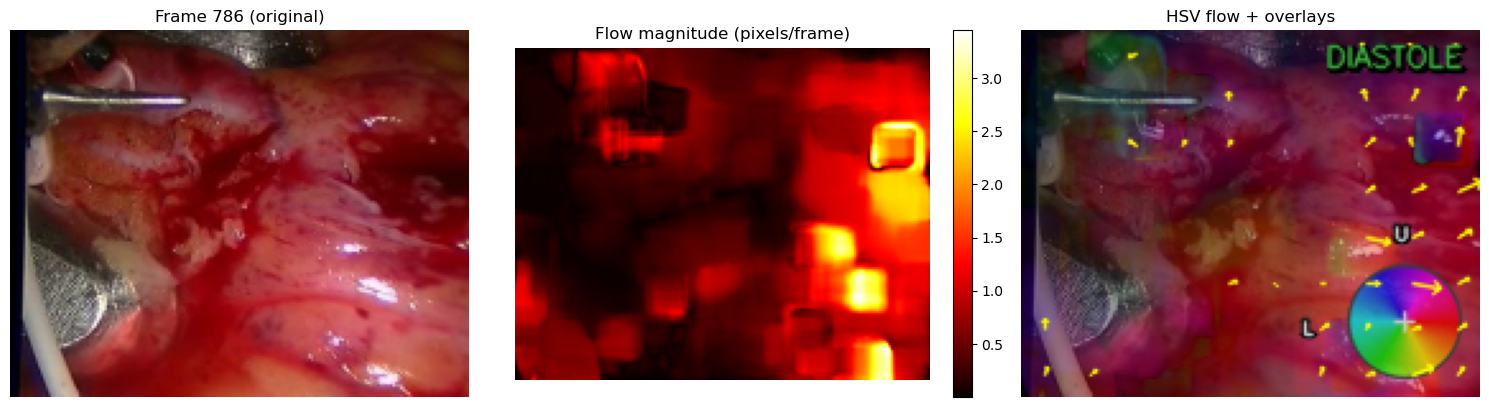

In [3]:
# Grab two consecutive frames from the middle of the video
frames = [(i, f) for i, f in utils.iter_frames(VIDEO_PATH, scale=0.5)]
mid = len(frames) // 2
_, prev_bgr = frames[mid]
_, curr_bgr = frames[mid + 1]

prev_gray = cv2.cvtColor(prev_bgr, cv2.COLOR_BGR2GRAY)
curr_gray = cv2.cvtColor(curr_bgr, cv2.COLOR_BGR2GRAY)

# Compute flow
flow_raw = cv2.calcOpticalFlowFarneback(
    prev_gray, curr_gray, None,
    pyr_scale=0.5, levels=3, winsize=15,
    iterations=3, poly_n=5, poly_sigma=1.2, flags=0
)
magnitude, angle = cv2.cartToPolar(flow_raw[..., 0], flow_raw[..., 1])

# Build annotated frame
annotated = tracker.flow_to_hsv_frame(magnitude, angle, curr_bgr)
visualizer.draw_colorbar(annotated)
visualizer.draw_motion_vectors(annotated, flow_raw, step=18, scale=4.0)

history = collections.deque(maxlen=15)
phase = visualizer.draw_phase_indicator(annotated, float(magnitude.mean()), history)
print(f'Phase at frame {mid}: {phase}  (mean mag = {magnitude.mean():.2f} px)')

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cv2.cvtColor(prev_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Frame {mid} (original)')
axes[0].axis('off')

axes[1].imshow(magnitude, cmap='hot')
axes[1].set_title('Flow magnitude (pixels/frame)')
axes[1].axis('off')
plt.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046)

axes[2].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
axes[2].set_title('HSV flow + overlays')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 3. Heartbeat magnitude signal

Plot mean optical flow magnitude over time.  
Peaks = systole (contraction), troughs = diastole.

Computing magnitude signal (this takes ~30s at half-res)...


  magnitude_signal: 100 frames

  magnitude_signal: 200 frames

  magnitude_signal: 300 frames

  magnitude_signal: 400 frames

...

  magnitude_signal: 1100 frames

  magnitude_signal: 1200 frames

  magnitude_signal: 1300 frames

  magnitude_signal: 1400 frames

  magnitude_signal: 1500 frames

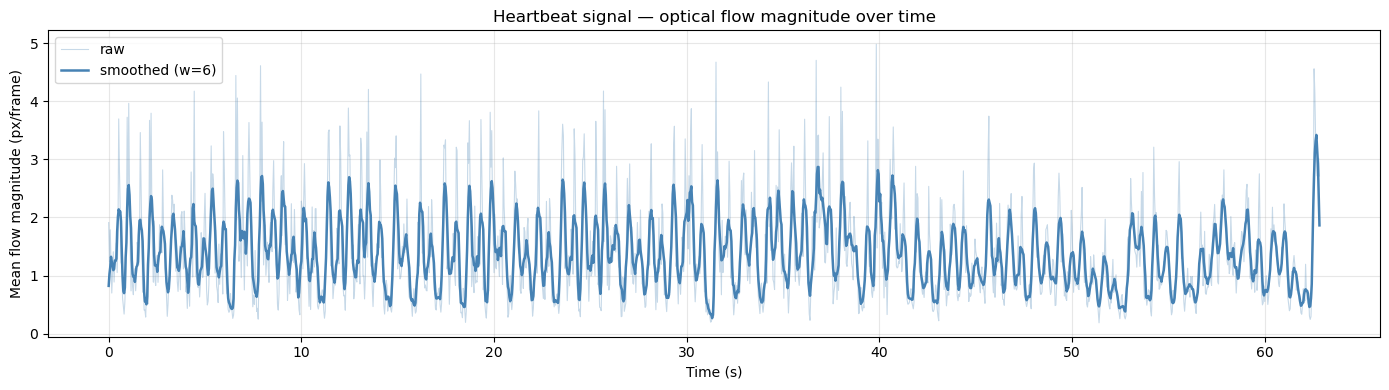

Estimated heart rate: 95.4 bpm  (dominant frequency: 1.59 Hz)


In [4]:
print('Computing magnitude signal (this takes ~30s at half-res)...')
signal = utils.magnitude_signal(VIDEO_PATH, scale=0.5)

fps = info['fps']
times = [i / fps for i in range(len(signal))]

# Smooth with a short rolling mean to reduce noise
window = max(1, int(fps // 4))
kernel = np.ones(window) / window
smoothed = np.convolve(signal, kernel, mode='same')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(times, signal, alpha=0.3, color='steelblue', linewidth=0.8, label='raw')
ax.plot(times, smoothed, color='steelblue', linewidth=1.8, label=f'smoothed (w={window})')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Mean flow magnitude (px/frame)')
ax.set_title('Heartbeat signal — optical flow magnitude over time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Rough heart rate estimate via FFT
from numpy.fft import rfft, rfftfreq
detrended = smoothed - smoothed.mean()
freqs = rfftfreq(len(detrended), d=1.0 / fps)
power = np.abs(rfft(detrended))
# Only look in the physiological range: 0.5–3.5 Hz (30–210 bpm)
mask = (freqs >= 0.5) & (freqs <= 3.5)
dominant_freq = freqs[mask][np.argmax(power[mask])]
print(f'Estimated heart rate: {dominant_freq * 60:.1f} bpm  (dominant frequency: {dominant_freq:.2f} Hz)')

## 4. Strain map — cumulative deformation over 1 second

Accumulates flow magnitude over a 1-second sliding window.  
**Red** = tissue with sustained high displacement (myocardium).  
**Blue** = static regions (fat, background).

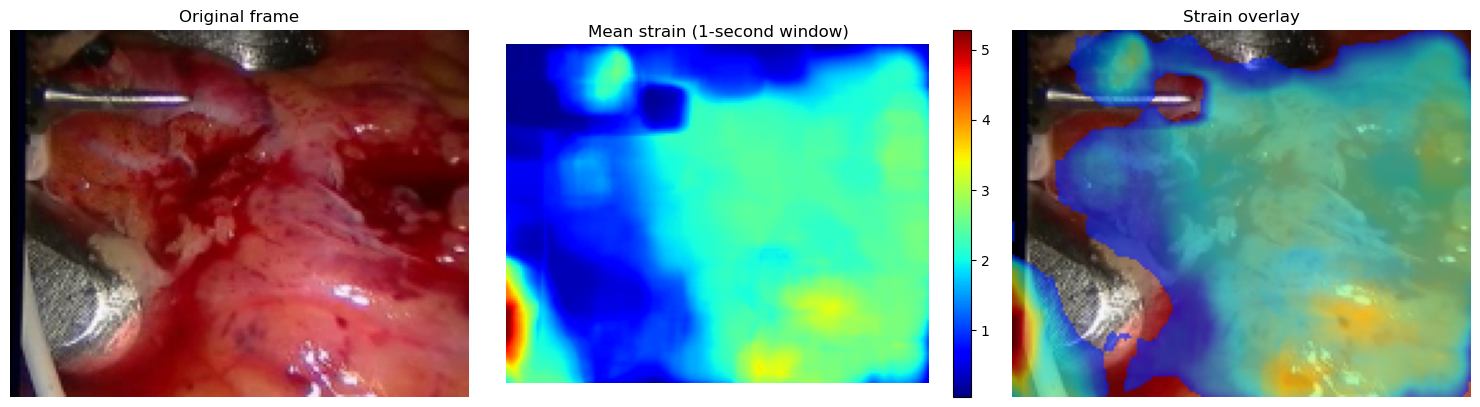

Red = high sustained motion (myocardium), Blue = static tissue


In [5]:
fps_int = int(info['fps'])
all_frames = [(i, f) for i, f in utils.iter_frames(VIDEO_PATH, scale=0.5)]
start = len(all_frames) // 2

# Build 1-second magnitude history from mid-video
mag_history = collections.deque(maxlen=fps_int)
prev_gray = cv2.cvtColor(all_frames[start][1], cv2.COLOR_BGR2GRAY)
for _, frame in all_frames[start + 1 : start + fps_int + 2]:
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    mag_arr, _, _ = tracker.compute_flow(prev_gray, gray)
    mag_history.append(mag_arr)
    prev_gray = gray

# Render strain overlay
sample = all_frames[start + fps_int][1].copy()
visualizer.draw_strain_map(sample, mag_history, alpha=0.6)

# Raw mean strain heatmap
h, w = sample.shape[:2]
stack = np.stack([cv2.resize(m, (w, h)) for m in mag_history], axis=0)
mean_strain = stack.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(cv2.cvtColor(all_frames[start + fps_int][1], cv2.COLOR_BGR2RGB))
axes[0].set_title('Original frame')
axes[0].axis('off')

im = axes[1].imshow(mean_strain, cmap='jet')
axes[1].set_title('Mean strain (1-second window)')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

axes[2].imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
axes[2].set_title('Strain overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()
print('Red = high sustained motion (myocardium), Blue = static tissue')

## 5. Export full annotated video

In [6]:
tracker.process_video(
    input_path=VIDEO_PATH,
    output_path=OUTPUT_PATH,
    scale=0.5,
)
print(f'Output saved to: {OUTPUT_PATH.resolve()}')

[INFO] Input : ..\data\hamlyn_seq04.avi  (360×288 @ 25.0 fps, 1573 frames)
[INFO] Output: ..\outputs\demo_flow.mp4  (180×144 @ 25.0 fps)


[INFO] 50/1573 frames processed (3.2%)


[INFO] 100/1573 frames processed (6.4%)


[INFO] 150/1573 frames processed (9.5%)


[INFO] 200/1573 frames processed (12.7%)


...

[INFO] 1350/1573 frames processed (85.8%)


[INFO] 1400/1573 frames processed (89.0%)


[INFO] 1450/1573 frames processed (92.2%)


[INFO] 1500/1573 frames processed (95.4%)


[INFO] 1550/1573 frames processed (98.5%)
[DONE] Wrote 1573 frames → ..\outputs\demo_flow.mp4
Output saved to: C:\Users\dprad\Downloads\heart-beat-tracker\outputs\demo_flow.mp4


## References

**Dataset**

Mountney, P., Stoyanov, D., Davison, A., & Yang, G.-Z. (2010).
*Simultaneous Stereoscope Localization and Soft-Tissue Mapping for Minimal Invasive Surgery.*
Medical Image Computing and Computer-Assisted Intervention (MICCAI), LNCS vol. 6361, pp. 251–258.
https://doi.org/10.1007/978-3-642-15705-9_31

Stoyanov, D., Scarzanella, M. V., Pratt, P., & Yang, G.-Z. (2010).
*Real-Time Stereo Reconstruction in Robotically Assisted Minimally Invasive Surgery.*
Medical Image Computing and Computer-Assisted Intervention (MICCAI), LNCS vol. 6361, pp. 275–282.
https://doi.org/10.1007/978-3-642-15705-9_34

Recasens, A. (2023). *HamlynRectifiedDataset* [Data set]. Hugging Face.
https://huggingface.co/datasets/Recasens/HamlynRectifiedDataset

**Algorithm**

Farnebäck, G. (2003).
*Two-Frame Motion Estimation Based on Polynomial Expansion.*
Scandinavian Conference on Image Analysis (SCIA), LNCS vol. 2749, pp. 363–370.
https://doi.org/10.1007/3-540-45103-X_50

**Libraries**

Bradski, G. (2000). *The OpenCV Library.* Dr. Dobb's Journal of Software Tools, 25(11), 120–125.
https://opencv.org

Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020).
*Array programming with NumPy.* Nature, 585, 357–362.
https://doi.org/10.1038/s41586-020-2649-2

Hunter, J. D. (2007).
*Matplotlib: A 2D Graphics Environment.*
Computing in Science & Engineering, 9(3), 90–95.
https://doi.org/10.1109/MCSE.2007.55